# 3D visualization in dynamo

dynamo v1.4 ships a full suite of **3D visualizations** built on matplotlib, Plotly and PyVista:

| function | what it draws | backends |
|---|---|---|
| `dyn.pl.scatters_interactive` | interactive 3D scatter | Plotly, PyVista |
| `dyn.pl.cell_wise_vectors_3d` | per-cell velocity vectors | matplotlib, PyVista |
| `dyn.pl.topography_3D` | vector-field topography (fixed points + streamlines) | matplotlib, PyVista |
| `dyn.pl.plot_3d_streamtube` | fate streamtubes | Plotly |
| `dyn.mv.PyvistaAnim` | 3D fate animation | PyVista |

This tutorial walks through each on a real RNA-velocity dataset. Static (matplotlib) and Plotly plots are rendered inline; the PyVista/animation calls are shown as code you can run locally for an interactive window.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.display import HTML, display
import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')

def show_plotly(fig):
    """Embed a Plotly figure inline (interactive) so it renders in the static notebook."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

## 1. Preprocess, estimate velocity, and build a 3D embedding

We use the zebrafish sample dataset, run the standard dynamo workflow, then compute a **3-component** UMAP (`n_components=3`, `enforce=True`) and project velocities onto it with `cell_velocities`.

In [2]:
adata = dyn.sample_data.zebrafish()
celltype_key = 'Cell_type'

preprocessor = dyn.pp.Preprocessor()
preprocessor.preprocess_adata(adata, recipe='monocle')
dyn.tl.dynamics(adata, model='stochastic', cores=4)

dyn.tl.reduceDimension(adata, basis='umap', n_components=3, enforce=True)
dyn.tl.cell_velocities(adata, basis='umap')
print('X_umap:', adata.obsm['X_umap'].shape, '| velocity_umap:', adata.obsm['velocity_umap'].shape)

|-----> File ./data/zebrafish.h5ad already exists.


|-----> Running monocle preprocessing pipeline...


|-----------> filtered out 14 outlier cells


|-----------> filtered out 12746 outlier genes


|-----> PCA dimension reduction


...

|-----> [projecting velocity vector to low dimensional embedding] completed [0.4436s]


|-----> method arg is None, choosing methods automatically...


|-----------> method kd_tree selected



╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮
│  Duration: 4.6619s                                                 │
│  Shape:    4,167 x 16,940 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_transition (bool)                            │
│                                                                    │
│  ● UNS    │ ✚ grid_velocity_umap                                   │
│                                                                    │
│  ● OBSP   │ ✚ connectivities (sparse matrix, 4167x4167)            │
│           │ ✚ distances (sparse matrix, 4167x4167)                 │
│           │ ✚ pearson_transition_matrix (sparse matrix, 4167x4167) │
│                                                                    │
│  ● 

X_umap: (4167, 3) | velocity_umap: (4167, 3)


## 2. Interactive 3D scatter — `scatters_interactive`

`dyn.pl.scatters_interactive` draws an interactive 3D scatter. With `plot_method='plotly'` it returns a Plotly figure you can rotate and zoom; here we embed it inline. (Use `plot_method='pv'` for a PyVista window locally.)

|-----------> plotting with basis key=X_umap


|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type


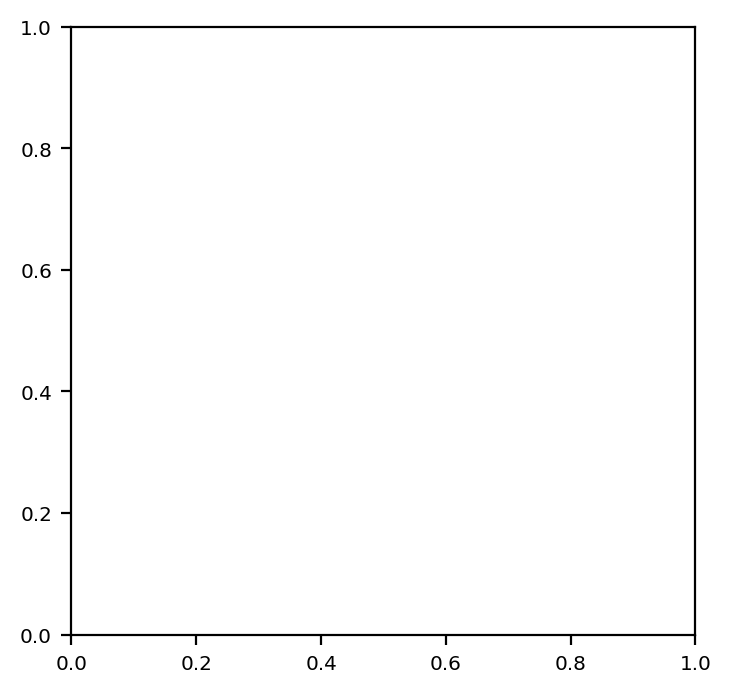

In [3]:
fig, _ = dyn.pl.scatters_interactive(
    adata, basis='umap', color=celltype_key, plot_method='plotly', save_show_or_return='return'
)
fig.update_layout(width=700, height=550)
show_plotly(fig)

## 3. 3D velocity vectors — `cell_wise_vectors_3d`

`dyn.pl.cell_wise_vectors_3d` draws one velocity arrow per cell in the 3D embedding. The static `matplotlib` renderer is used here (change the view with `elev` / `azim`).

|-----> X shape: (4167, 3) V shape: (4167, 3)


|-----------> plotting with basis key=X_umap


|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type


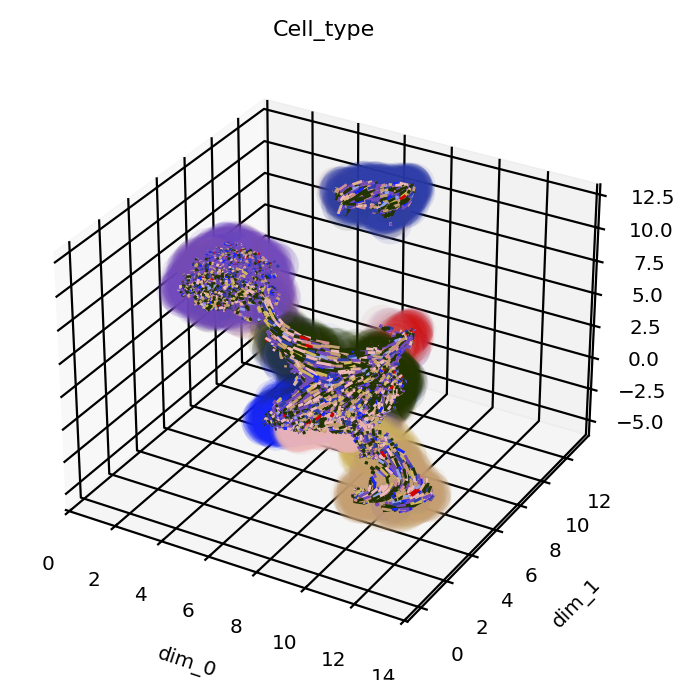

In [4]:
dyn.pl.cell_wise_vectors_3d(
    adata, basis='umap', color=[celltype_key], plot_method='matplotlib', elev=30, azim=-60
)

|-----> X shape: (4167, 3) V shape: (4167, 3)


|-----------> plotting with basis key=X_umap


|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type


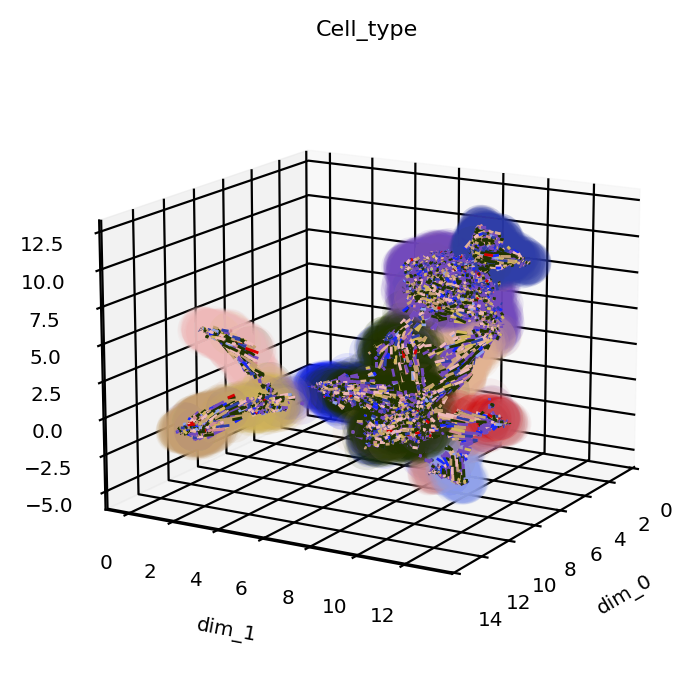

In [5]:
dyn.pl.cell_wise_vectors_3d(
    adata, basis='umap', color=[celltype_key], plot_method='matplotlib', elev=15, azim=30
)

## 4. 3D vector-field topography — `topography_3D`

After reconstructing a continuous vector field in 3D (`dyn.vf.VectorField`, `dims=3`) and identifying its fixed points (`dyn.vf.topography`), `dyn.pl.topography_3D` overlays the topology (fixed points) on the 3D embedding.

|-----> VectorField reconstruction begins...


|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.


|-----> Generating high dimensional grids and convert into a row matrix.


|-----> Learning vector field with method: sparsevfc.


|-----> [SparseVFC] begins...


...


╭─ SUMMARY: topography ──────────────────────────────────────────────╮
│  Duration: 0.0772s                                                 │
│  Shape:    4,167 x 16,940 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


|-----------> plotting with basis key=X_umap


|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type



╭─ EXPLANATION: FIXED POINTS ────────────────────────────────────────╮
│  What it measures:
│  Fixed points are steady states of the dynamical system where dx/dt = 0.│
│  Full circles are stable/unstable fixed points; half-circles are saddle points.│
│                                                                    │
│  Interpreting values:
│  ● Absorbing / attractors (black, filled): Stable terminal cell    │
│    types — all trajectories                                        │
│    converge here (e.g.,                                            │
│    melanophore, iridophore,                                        │
│    xanthophore, unknown                                            │
│    terminal states)                                                │
│  ● Emitting / repellers (red, filled): Progenitor/source states —  │
│    cells spontaneously                                             │
│    differentiate outward from                                      │
│    these poi

<Axes3D: title={'center': 'Cell_type'}, xlabel='umap_1', ylabel='umap_2', zlabel='umap_3'>

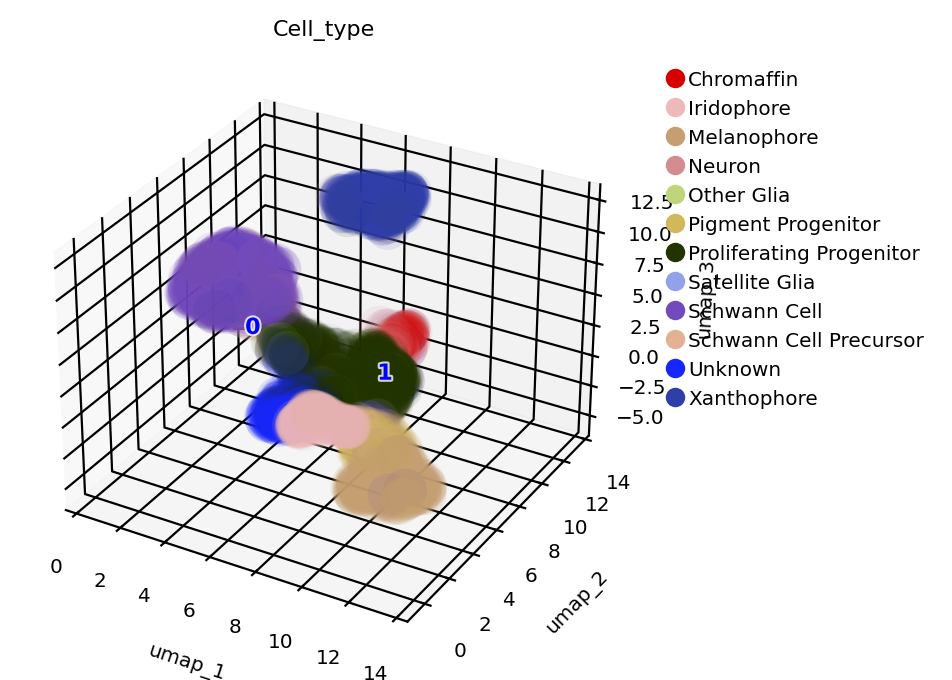

In [6]:
dyn.vf.VectorField(adata, basis='umap', dims=3)
dyn.vf.topography(adata, basis='umap', n=10)

dyn.pl.topography_3D(
    adata, basis='umap', color=[celltype_key], plot_method='matplotlib', save_show_or_return='return'
)

## 5. PyVista, streamtubes, and animation

The remaining 3D tools open interactive PyVista windows or write animation files, so they are best run locally rather than inside a static notebook. The calls are:

**Interactive PyVista renderers** (rotatable windows):

```python
# 3D scatter / velocity vectors / topography with PyVista
dyn.pl.scatters_interactive(adata, basis='umap', color=celltype_key, plot_method='pv')
dyn.pl.cell_wise_vectors_3d(adata, basis='umap', color=[celltype_key], plot_method='pv')
dyn.pl.topography_3D(adata, basis='umap', color=[celltype_key], plot_method='pv')
```

**Fate streamtubes** (`plot_3d_streamtube`, Plotly) — visualize least-action / fate trajectories grouped by a key, starting from an initial group:

```python
dyn.pl.plot_3d_streamtube(
    adata, color=celltype_key, layer='X', group=celltype_key,
    init_group='Progenitor', basis='umap',
)
```

**3D fate animation** (`dyn.mv.PyvistaAnim`) — animate cell-fate commitment after running fate prediction (`dyn.pd.fate`):

```python
dyn.pd.fate(adata, basis='umap', init_cells=adata.obs_names[:50])
anim = dyn.mv.PyvistaAnim(adata, basis='umap', filename='fate_animation.gif')
anim.animate()
```


## Summary

- Build a 3-component embedding (`reduceDimension(..., n_components=3)`) and project velocities (`cell_velocities`).
- **Static / inline:** `cell_wise_vectors_3d` and `topography_3D` (matplotlib), `scatters_interactive` (Plotly).
- **Interactive locally:** the same functions with `plot_method='pv'` (PyVista), `plot_3d_streamtube` (Plotly), and `dyn.mv.PyvistaAnim` (animation).
